# Тестовое задание риск-анализ
Переформулирую задачу для своего собственного понимания, что нужно...
Компания выдаёт ипотечные кредиты. Отдел рисков должен одновременно:
1. удерживать уровень просрочки выдаваемого портфеля на уровне 1% ... 1 кредит из 100
2. максимизировать уровень одобрения заявок

Гипотеза. Отношение первоначального взноса к стоимости недвижимости
(ПВ, поле initinal_payment) хорошо ранжирует платёжеспособность клиента, чем больше собственных средств вносит клиент, тем ниже вероятность просрочки

> Все числовые выводы в аналитической записке получены из этого ноутбука 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
RNG = np.random.default_rng(42)

def auc_score(y, score):
    # score — чем больше, тем выше ожидаемый риск
    y = np.asarray(y)
    r = pd.Series(score).rank().values
    n1 = y.sum(); n0 = len(y) - n1
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def gini(y, score):
    return 2 * auc_score(y, score) - 1

def roc_curve(y, score):
    order = np.argsort(-np.asarray(score))
    y = np.asarray(y)[order]
    tpr = np.cumsum(y) / y.sum()
    fpr = np.cumsum(1 - y) / (len(y) - y.sum())
    return np.r_[0, fpr], np.r_[0, tpr]

## 1. Загрузка и разведочный анализ

In [3]:
df = pd.read_csv('data/dataset.csv', sep=';')
print('Размер выборки:', df.shape)
print('Уровень просрочки в портфеле:', f'{df.delay.mean():.4f}  ({df.delay.mean()*100:.2f}%)')
df.head()

Размер выборки: (7307, 4)
Уровень просрочки в портфеле: 0.0242  (2.42%)


,application_id,pd,initinal_payment,delay
0,1,0.0540,0.2900,0
1,2,0.1380,0.1830,0
2,3,0.1350,0.2440,0
3,4,0.0420,0.2710,0
4,5,0.0580,0.1740,0


In [4]:
df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
application_id,3654.0000,2109.4935,1.0000,1827.5000,3654.0000,5480.5000,7307.0000
pd,0.0536,0.0325,0.0000,0.0310,0.0450,0.0650,0.2490
initinal_payment,0.2792,0.0772,0.0060,0.2250,0.2820,0.3390,0.4940
delay,0.0242,0.1538,0.0000,0.0000,0.0000,0.0000,1.0000


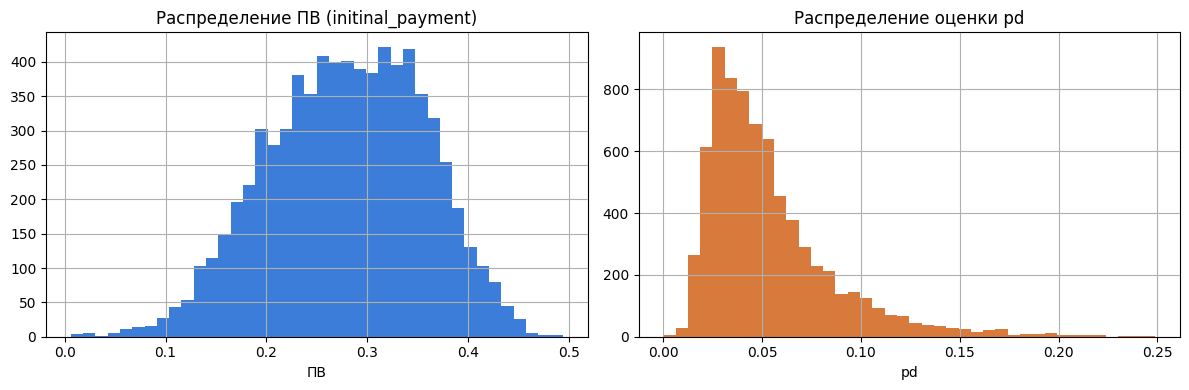

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df.initinal_payment, bins=40, color='#3b7dd8')
ax[0].set_title('Распределение ПВ (initinal_payment)'); ax[0].set_xlabel('ПВ')
ax[1].hist(df.pd, bins=40, color='#d87a3b')
ax[1].set_title('Распределение оценки pd'); ax[1].set_xlabel('pd')
plt.tight_layout(); plt.show()

Данные без пропусков.. ПВ лежит в диапазоне ~0.6%–49% со средним ~28%.
Уровень просрочки в ретро-портфеле — 2.4%, то есть текущая политика не проходит целевой уровень 1% и требует ужесточения

## 2. Проверка гипотезы
Ранжирует ли ПВ платёжеспособность

In [6]:
corr = df[['pd', 'initinal_payment', 'delay']].corr()['delay']
print('Корреляция с флагом просрочки:')
print(f'ПВ  vs delay: {corr.initinal_payment:+.3f}')
print(f'pd  vs delay: {corr.pd:+.3f}')

Корреляция с флагом просрочки:
ПВ  vs delay: -0.103
pd  vs delay: +0.099


In [7]:
# Уровень просрочки по децилям ПВ
df['pv_decile'] = pd.qcut(df.initinal_payment, 10, labels=False) + 1
tab = df.groupby('pv_decile').agg(
    pv_min=('initinal_payment', 'min'),
    pv_max=('initinal_payment', 'max'),
    default_rate=('delay', 'mean'),
    n=('delay', 'size'))
tab

,pv_min,pv_max,default_rate,n
pv_decile,,,,
1,0.0060,0.1760,0.0566,742
2,0.1770,0.2100,0.0495,728
3,0.2110,0.2360,0.0263,723
4,0.2370,0.2600,0.0256,743
5,0.2610,0.2820,0.0204,735
6,0.2830,0.3050,0.0181,719
7,0.3060,0.3280,0.0184,762
8,0.3290,0.3490,0.0168,715
9,0.3500,0.3770,0.0055,730


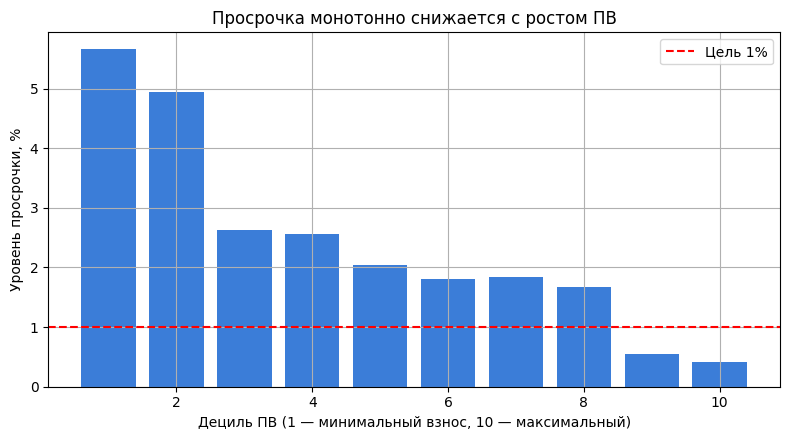

In [8]:
fig, ax = plt.subplots()
ax.bar(tab.index, tab.default_rate * 100, color='#3b7dd8')
ax.axhline(1.0, color='red', ls='--', label='Цель 1%')
ax.set_xlabel('Дециль ПВ (1 — минимальный взнос, 10 — максимальный)')
ax.set_ylabel('Уровень просрочки, %')
ax.set_title('Просрочка монотонно снижается с ростом ПВ')
ax.legend(); plt.tight_layout(); plt.show()

Gini(ПВ) = 0.370   (AUC = 0.685)
Gini(pd) = 0.328   (AUC = 0.664)


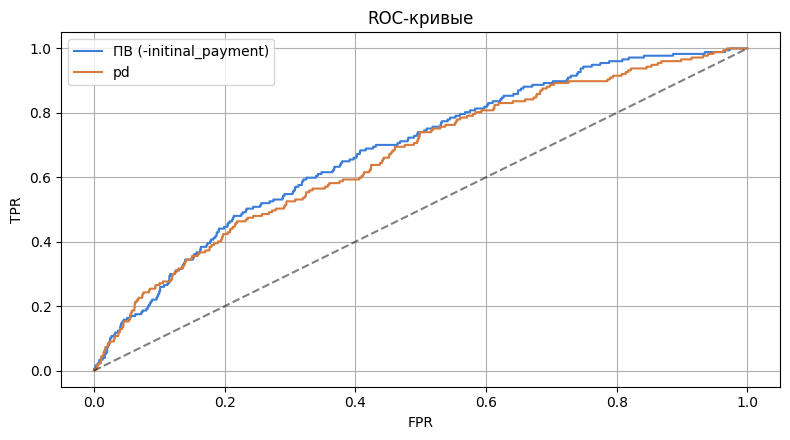

In [9]:
# Gini/ROC-AUC... Для ПВ риск растёт при уменьшении взноса, поэтому в качестве скора риска берём
g_pv = gini(df.delay, -df.initinal_payment)
g_pd = gini(df.delay, df.pd)
print(f'Gini(ПВ) = {g_pv:.3f}   (AUC = {(g_pv+1)/2:.3f})')
print(f'Gini(pd) = {g_pd:.3f}   (AUC = {(g_pd+1)/2:.3f})')

fig, ax = plt.subplots()
for name, score, c in [('ПВ (-initinal_payment)', -df.initinal_payment, '#3b7dd8'),
                       ('pd', df.pd, '#d87a3b')]:
    fpr, tpr = roc_curve(df.delay, score)
    ax.plot(fpr, tpr, label=f'{name}', color=c)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC-кривые')
ax.legend(); plt.tight_layout(); plt.show()

Вывод по гипотезе
Гипотеза подтверждается:
* уровень просрочки монотонно снижается от 5.7% в нижнем дециле ПВ до 0.4% в верхнем;
* ранжирующая способность ПВ (Gini ≈ 0.37) даже немного выше, чем у действующего
  показателя pd (Gini ≈ 0.33);
* корреляция ПВ с просрочкой отрицательная (−0.10)
ПВ пригоден как самостоятельный ранжирующий фактор для решающего правила.

## 3. Подбор порога по ПВ под цель просрочка ≤ 1%

In [10]:
N = len(df)
rows = []
for t in np.round(np.arange(0.20, 0.40, 0.005), 3):
    sub = df[df.initinal_payment >= t]
    rows.append((t, len(sub) / N, sub.delay.mean()))
grid = pd.DataFrame(rows, columns=['threshold', 'approval_share', 'portfolio_default'])

ok = grid[grid.portfolio_default <= 0.01].iloc[0]
print(f'Минимальный порог для просрочки ≤ 1%: ПВ ≥ {ok.threshold:.3f}')
print(f'  доля одобрения от исходного пула: {ok.approval_share:.3f}')
print(f'  ожидаемая просрочка: {ok.portfolio_default:.4f}')
grid[(grid.threshold >= 0.28) & (grid.threshold <= 0.35)]

Минимальный порог для просрочки ≤ 1%: ПВ ≥ 0.320
  доля одобрения от исходного пула: 0.335
  ожидаемая просрочка: 0.0086


,threshold,approval_share,portfolio_default
16,0.2800,0.5124,0.0131
17,0.2850,0.4879,0.0126
18,0.2900,0.4676,0.0126
19,0.2950,0.4434,0.0117
20,0.3000,0.4232,0.0113
21,0.3050,0.4041,0.0112
22,0.3100,0.3805,0.0104
23,0.3150,0.3546,0.0100
24,0.3200,0.3346,0.0086
25,0.3250,0.3141,0.0087


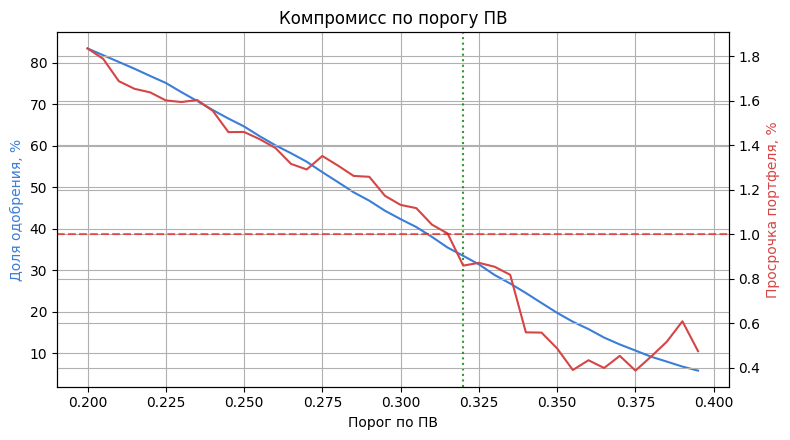

In [11]:
fig, ax1 = plt.subplots()
ax1.plot(grid.threshold, grid.approval_share * 100, color='#3b7dd8', label='Доля одобрения')
ax1.set_xlabel('Порог по ПВ'); ax1.set_ylabel('Доля одобрения, %', color='#3b7dd8')
ax2 = ax1.twinx()
ax2.plot(grid.threshold, grid.portfolio_default * 100, color='#d64545', label='Просрочка')
ax2.axhline(1.0, color='red', ls='--', alpha=0.6)
ax2.set_ylabel('Просрочка портфеля, %', color='#d64545')
ax1.axvline(0.32, color='green', ls=':', alpha=0.8)
ax1.set_title('Компромисс по порогу ПВ')
plt.tight_layout(); plt.show()

In [ ]:
# ПВ >= 0.315 даёт ровно ~1%. Для запаса устойчивости оцениваем 95% бутстреп-интервал просрочки при рабочем пороге 0.32.
def boot_default(threshold, n_boot=2000):
    sub = df[df.initinal_payment >= threshold].delay.values
    est = [RNG.choice(sub, len(sub), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(est, [2.5, 97.5])

for t in [0.315, 0.32]:
    sub = df[df.initinal_payment >= t]
    lo, hi = boot_default(t)
    print(f'ПВ ≥ {t}: одобрение {len(sub)/N:.3f}, '
          f'просрочка {sub.delay.mean():.4f}  95% ДИ [{lo:.4f}; {hi:.4f}]')

ПВ ≥ 0.315: одобрение 0.355, просрочка 0.0100  95% ДИ [0.0066; 0.0139]
ПВ ≥ 0.32: одобрение 0.335, просрочка 0.0086  95% ДИ [0.0049; 0.0127]


Точечно цель 1% достигается при ПВ >= 0.315 (просрочка ровно 1%,
одобряется ~35.5% пула)... Верхняя граница 95% доверительного интервала на этом пороге
касается 1%, поэтому как рабочий порог рекомендуется ПВ >= 0.32, тогда ожидаемая просрочка
0.86%, одобрение ~33.5%

### Сравнение при одинаковой цели 1%
Ранжируем портфель по каждому фактору и одобряем максимально возможную долю так, чтобы
накопленная просрочка не превышала 1%

Макс. одобрение при просрочке ≤ 1%:
ранжирование по ПВ: 0.368
ранжирование по pd: 0.249


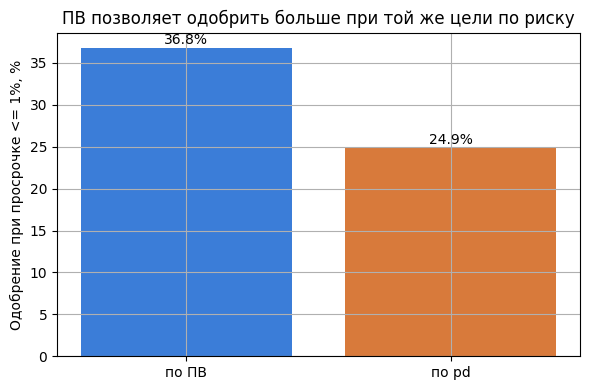

In [12]:
def max_approval_at_target(score_ascending, target=0.01):
    d = df.assign(s=score_ascending).sort_values('s')
    d['cum'] = d.delay.expanding().mean()
    return (d['cum'] <= target).sum() / len(d)

appr_pv = max_approval_at_target(-df.initinal_payment)
appr_pd = max_approval_at_target(df.pd)
print(f'Макс. одобрение при просрочке ≤ 1%:')
print(f'ранжирование по ПВ: {appr_pv:.3f}')
print(f'ранжирование по pd: {appr_pd:.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['по ПВ', 'по pd'], [appr_pv*100, appr_pd*100], color=['#3b7dd8', '#d87a3b'])
for i, v in enumerate([appr_pv, appr_pd]):
    ax.text(i, v*100+0.5, f'{v*100:.1f}%', ha='center')
ax.set_ylabel('Одобрение при просрочке <= 1%, %')
ax.set_title('ПВ позволяет одобрить больше при той же цели по риску')
plt.tight_layout(); plt.show()

При одинаковой цели по риску ранжирование по ПВ одобряет ~36.6% против 24.9% у pd —
то есть примерно на 47% больше объёма

## 4. Машинка
подумала провести эксперимент по базе...
ПВ — сильный одиночный фактор. Проверим, даёт ли комбинация факторов (логистическая
регрессия на pd и ПВ) заметный выигрыш. Это оценка "потолка", чтобы принять осознанное
решение... усложнять ли СПР ради дополнительного одобрения

In [13]:
def fit_logreg(X, y, lr=0.5, n_iter=4000):
    Xb = np.c_[np.ones(len(X)), (X - X.mean(0)) / X.std(0)]
    w = np.zeros(Xb.shape[1])
    for _ in range(n_iter):
        p = 1 / (1 + np.exp(-Xb @ w))
        w -= lr * Xb.T @ (p - y) / len(y)
    return 1 / (1 + np.exp(-Xb @ w)), w

X = df[['pd', 'initinal_payment']].values.astype(float)
proba, w = fit_logreg(X, df.delay.values.astype(float))
g_ml = gini(df.delay, proba)
appr_ml = max_approval_at_target(proba)
print(f'Комбинированная модель pd+ПВ:  Gini = {g_ml:.3f}')
print(f'Макс. одобрение при просрочке ≤ 1%: {appr_ml:.3f}')

summary = pd.DataFrame({
    'Подход': ['pd (текущий)', 'ПВ (одиночный порог)', 'ML: pd + ПВ'],
    'Gini': [g_pd, g_pv, g_ml],
    'Одобрение при просрочке <=1%': [appr_pd, appr_pv, appr_ml]})
summary

Комбинированная модель pd+ПВ:  Gini = 0.427
Макс. одобрение при просрочке ≤ 1%: 0.471


/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11109/482856191.py:5: RuntimeWarning: divide by zero encountered in matmul
  p = 1 / (1 + np.exp(-Xb @ w))
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11109/482856191.py:5: RuntimeWarning: overflow encountered in matmul
  p = 1 / (1 + np.exp(-Xb @ w))
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11109/482856191.py:5: RuntimeWarning: invalid value encountered in matmul
  p = 1 / (1 + np.exp(-Xb @ w))
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11109/482856191.py:7: RuntimeWarning: divide by zero encountered in matmul
  return 1 / (1 + np.exp(-Xb @ w)), w
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11109/482856191.py:7: RuntimeWarning: overflow encountered in matmul
  return 1 / (1 + np.exp(-Xb @ w)), w
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11109/482856191.py:7: RuntimeWarning: invalid value encountered in matmul
  return 1 / (1 + np.exp(-Xb @ w)), w


,Подход,Gini,Одобрение при просрочке <=1%
0,pd (текущий),0.3279,0.2488
1,ПВ (одиночный порог),0.3700,0.3679
2,ML: pd + ПВ,0.4269,0.4705


### Вывод
Комбинированная модель повышает Gini до 0.43 и потенциально одобрение
до 47% — прирост порядка +10 п.п к одиночному ПВ. Выигрыш реальный, но он достаётся ценой усложнения...  модель нужно валидировать, мониторить, объяснять и поддерживать

Получается, рекомендуется всё же на первом шаге внедрить правило-порог по ПВ (быстро, легко тестируется), а ML-скоркарту рассматривать как следующую итерацию, думаю... когда потребуется дожать уровень одобрения

## 5. Оценка эффекта на уровень одобрения

In [14]:
app = pd.read_csv('data/БД/spr_application.csv', sep=';')
feat = pd.read_csv('data/БД/spr_features.csv', sep=';')
req = pd.read_csv('data/БД/spr_request.csv', sep=';')
print('Заявок:', app.application_id.nunique(), '| источники:', app.source.value_counts().to_dict())
print(req.groupby(['request_type', 'status']).size())

Заявок: 1000 | источники: {'B2B': 810, 'SITE': 190}
request_type       status 
FULL_APPLICATION   APPROVE    239
                   DECLINE    581
SHORT_APPLICATION  DECLINE    180
                   NEXT       820
dtype: int64


In [15]:
full = (req[req.request_type == 'FULL_APPLICATION']
        .merge(feat, left_on='spr_features_id', right_on='id')
        .merge(app[['application_id', 'source']], on='application_id'))
total_apps = app.application_id.nunique()
approved_before = (full.status == 'APPROVE').sum()

TH = 0.32
approved_after = ((full.status == 'APPROVE') & (full.initinal_payment >= TH)).sum()
print(f'Всего заявок: {total_apps}')
print(f'Одобрено сейчас: {approved_before}  ({approved_before/total_apps*100:.1f}%)')
print(f'Одобрено после правила: {approved_after}  ({approved_after/total_apps*100:.1f}%)')
print(f'Снятие с одобрения: {approved_before - approved_after} заявок')

Всего заявок: 1000
Одобрено сейчас: 239  (23.9%)
Одобрено после правила: 117  (11.7%)
Снятие с одобрения: 122 заявок


Рискованных одобрений (APPROVE, ПВ < 0.32): 122 из 239 (51% текущих одобрений)
Безопасных отказов (DECLINE, ПВ >= 0.32):  155 — кандидаты на пересмотр


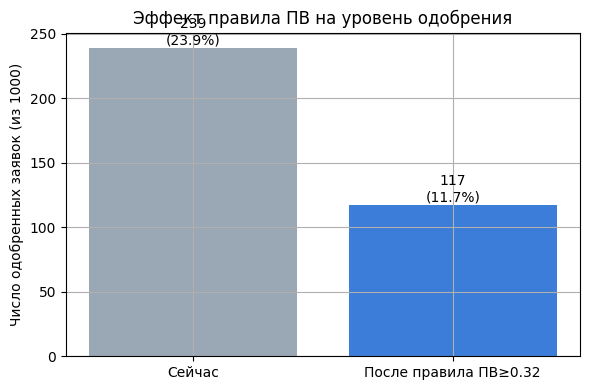

In [17]:
risky_approved = ((full.status == 'APPROVE') & (full.initinal_payment < TH)).sum()
safe_declined  = ((full.status == 'DECLINE') & (full.initinal_payment >= TH)).sum()
print(f'Рискованных одобрений (APPROVE, ПВ < {TH}): {risky_approved} из {approved_before} '
      f'({risky_approved/approved_before*100:.0f}% текущих одобрений)')
print(f'Безопасных отказов (DECLINE, ПВ >= {TH}):  {safe_declined} — кандидаты на пересмотр')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Сейчас', 'После правила ПВ≥0.32'], [approved_before, approved_after],
       color=['#9aa7b4', '#3b7dd8'])
for i, v in enumerate([approved_before, approved_after]):
    ax.text(i, v+3, f'{v}\n({v/total_apps*100:.1f}%)', ha='center')
ax.set_ylabel('Число одобренных заявок (из 1000)')
ax.set_title('Эффект правила ПВ на уровень одобрения')
plt.tight_layout(); plt.show()

In [18]:
# Эффект в разрезе источника
by_src = full[full.status == 'APPROVE'].assign(keep=lambda d: d.initinal_payment >= TH) \
    .groupby('source').agg(approved_before=('status', 'size'), approved_after=('keep', 'sum'))
by_src

,approved_before,approved_after
source,,
B2B,186,91
SITE,53,26


### Итог

* Правило-фильтр ПВ >= 0.32, добавленное на шаг FULL_APPLICATION, снижает одобрение с
  23.9% до 11.7% (117 из 1000). Снижение ожидаемо... для цели 1% политику необходимо ужесточать.
* Больше половины текущих одобрений (122 из 239) это заявки с ПВ ниже порога, то есть
  повышенного риска, и правило отсекает именно их
* При этом 155 отклонённых заявок имеют высокий ПВ — это управляемый потенциал роста
  одобрения на следующих итерациях, а не потеря...